# Νευρωνικό δίκτυο (MLP)

Ένα notebook, τρία βήματα: fine-tuning, τελική εκπαίδευση, αξιολόγηση στα
Test set 1 και 2. Το εκπαιδευμένο δίκτυο αποθηκεύεται στο `models/mlp_cutoff{50,20}/`,
ώστε το `neural_network_shap.ipynb` να το φορτώσει για την ερμηνεία με SHAP.

**Δεδομένα**: τα 1142 training μόρια με όλους τους 1672 descriptors όπως βγαίνουν από
το preprocessing. Τα test sets χρησιμοποιούνται μόνο στο Βήμα 3.

**Σταθερά σε όλες τις διαμορφώσεις**

- κάθε κρυφό στρώμα: `Dense → LayerNormalization → ReLU → Dropout`
- optimizer: **Adam**
- **early stopping** στο validation ROC-AUC, με επαναφορά των καλύτερων βαρών
  (το validation είναι το 15% του training — το fold αξιολόγησης δεν συμμετέχει)
- `RobustScaler` μέσα σε κάθε fold, με αποκοπή στο ±10

**Τι ρυθμίζεται στο fine-tuning**

| Υπερπαράμετρος | Τιμές |
|---|---|
| πλήθος κρυφών στρωμάτων | 1, 2, 3 |
| νευρώνες ανά στρώμα | 64, 128, 256 |
| dropout | 0.2, 0.35, 0.5 |

27 διαμορφώσεις, αξιολογημένες με **5-fold cross-validation** και **ROC-AUC** —
το ίδιο πρωτόκολλο με τα προηγούμενα μοντέλα.

**Χρόνος**: ~30–45 λεπτά, κυρίως το Βήμα 1. Για γρήγορη δοκιμή, μίκρυνε τις
λίστες `N_HIDDEN`, `NEURONS`, `DROPOUT` στο πρώτο κελί.


In [ ]:
# ============================== ΠΑΡΑΜΕΤΡΟΙ ==============================
label_case = 'label_cutoff_20%'   # 'label_cutoff_50%' | 'label_cutoff_20%'

RANDOM_STATE = 42

# ---- Το πλέγμα του fine-tuning: 3 × 3 × 3 = 27 διαμορφώσεις ----
N_HIDDEN = [1, 2, 3]              # πλήθος κρυφών στρωμάτων
NEURONS  = [64, 128, 256]         # νευρώνες ανά κρυφό στρώμα
DROPOUT  = [0.2, 0.35, 0.5]       # ποσοστό dropout

# ---- Σταθερά σε ΟΛΕΣ τις διαμορφώσεις ----
# Κάθε κρυφό στρώμα: Dense -> LayerNormalization -> ReLU -> Dropout
# Optimizer: Adam ·  Early stopping: στο validation ROC-AUC
LEARNING_RATE = 3e-4
EPOCHS        = 300
PATIENCE      = 25    # εποχές χωρίς βελτίωση πριν σταματήσει η εκπαίδευση
MIN_EPOCHS    = 10    # το early stopping αρχίζει να ελέγχει μετά από τόσες εποχές
BATCH         = 32
VAL_FRAC      = 0.15  # μέρος του training για early stopping
CLIP          = 10.0  # αποκοπή των κλιμακωμένων τιμών (βαριές ουρές στους descriptors)

SEEDS     = [42, 7, 123]   # η τελική πρόβλεψη είναι ο μέσος όρος τους
THRESHOLD = 0.5            # κατώφλι απόφασης στην αξιολόγηση


## Δεδομένα και το δίκτυο

In [8]:
# ==================== ΔΕΔΟΜΕΝΑ ΚΑΙ ΤΟ ΔΙΚΤΥΟ ====================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')

import time
import json
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
tf.config.experimental.enable_op_determinism()

TAG = label_case.replace('label_cutoff_', '').replace('%', '')
OUT = f'../results/Label_cutoff_{TAG}%/Neural_network'
os.makedirs(OUT, exist_ok=True)

# --------- δεδομένα: όλοι οι descriptors όπως βγαίνουν από το preprocessing ---------
features = [c for c in pd.read_csv('../Data/mordred_descriptors_without_NaN.csv',
                                   nrows=1).columns if c != 'SMILES']
train = pd.read_csv(f'../Data/merged_df_clean_{label_case}.csv')
train = train[train[label_case].notna()].reset_index(drop=True)
X = train[features]
y = train[label_case].astype(int).to_numpy()
medians = X.median()

# Τα ίδια 5 folds με τα προηγούμενα μοντέλα
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
FOLDS = list(cv.split(X, y))

print(f"Σενάριο  : {label_case}")
print(f"Features : {len(features)}")
print(f"Μόρια    : {len(y)} (High={int(y.sum())}, Low={int((y == 0).sum())})")
print(f"TensorFlow {tf.__version__} · Keras {keras.__version__}")


def build_model(n_in, n_hidden, neurons, dropout):
    """Κάθε κρυφό στρώμα: Dense -> LayerNormalization -> ReLU -> Dropout."""
    model = keras.Sequential([keras.Input(shape=(n_in,))])
    for _ in range(n_hidden):
        model.add(layers.Dense(neurons))
        model.add(layers.LayerNormalization())
        model.add(layers.Activation('relu'))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model


def fit_one(X_tr, y_tr, n_hidden, neurons, dropout, seed):
    """Εκπαίδευση σε ένα σύνολο. Ο scaler και το validation βγαίνουν μόνο από αυτό.

    Επιστρέφει (predict_fn, history, καλύτερη_εποχή).
    """
    keras.utils.set_random_seed(seed)
    scaler = RobustScaler().fit(X_tr)
    prep = lambda A: np.clip(scaler.transform(A), -CLIP, CLIP).astype('float32')

    i_fit, i_val = next(StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC,
                                               random_state=seed).split(X_tr, y_tr))
    Xp = prep(X_tr)
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr[i_fit])

    model = build_model(Xp.shape[1], n_hidden, neurons, dropout)
    stop = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=PATIENCE,
                                         start_from_epoch=MIN_EPOCHS,
                                         restore_best_weights=True)
    hist = model.fit(Xp[i_fit], y_tr[i_fit], validation_data=(Xp[i_val], y_tr[i_val]),
                     epochs=EPOCHS, batch_size=BATCH, class_weight={0: cw[0], 1: cw[1]},
                     callbacks=[stop], verbose=0)
    best_epoch = int(np.argmax(hist.history['val_auc'])) + 1
    return (lambda A: model.predict(prep(A), verbose=0).ravel()), hist, best_epoch


def cv_score(n_hidden, neurons, dropout, seed=RANDOM_STATE):
    """Out-of-fold πιθανότητες με τα 5 folds -> ROC-AUC."""
    oof = np.zeros(len(y))
    epochs = []
    for tr, te in FOLDS:
        predict, _, be = fit_one(X.iloc[tr], y[tr], n_hidden, neurons, dropout, seed)
        oof[te] = predict(X.iloc[te])
        epochs.append(be)
    return oof, float(np.mean(epochs))


def _save(df, path):
    try:
        df.to_csv(path, index=False, encoding='utf-8-sig')
        print(f"  {path}")
    except PermissionError:
        print(f"  ⚠ κλειδωμένο, δεν γράφτηκε: {path}")


Σενάριο  : label_cutoff_20%
Features : 1672
Μόρια    : 1142 (High=859, Low=283)
TensorFlow 2.20.0 · Keras 3.11.3


## Βήμα 1 — Fine-tuning

27 διαμορφώσεις × 5 folds = 135 εκπαιδεύσεις

  # layers  neurons  dropout   ROC-AUC  εποχές   χρόνος
--------------------------------------------------------
  1      1       64      0.2    0.7530      33      54s
  2      1       64     0.35    0.7336      32      44s
  3      1       64      0.5    0.7288      15      34s
  4      1      128      0.2    0.7371      31      47s
  5      1      128     0.35    0.7305      39      51s
  6      1      128      0.5    0.7323      31      46s
  7      1      256      0.2    0.7469      21      79s
  8      1      256     0.35    0.7374      40     114s
  9      1      256      0.5    0.7394      30     119s
 10      2       64      0.2    0.7349      21      50s
 11      2       64     0.35    0.7235      17      46s
 12      2       64      0.5    0.7113      32      45s
 13      2      128      0.2    0.7384      25      48s
 14      2      128     0.35    0.7270      26      48s
 15      2      128      0.5    0.7202      40      61s
 

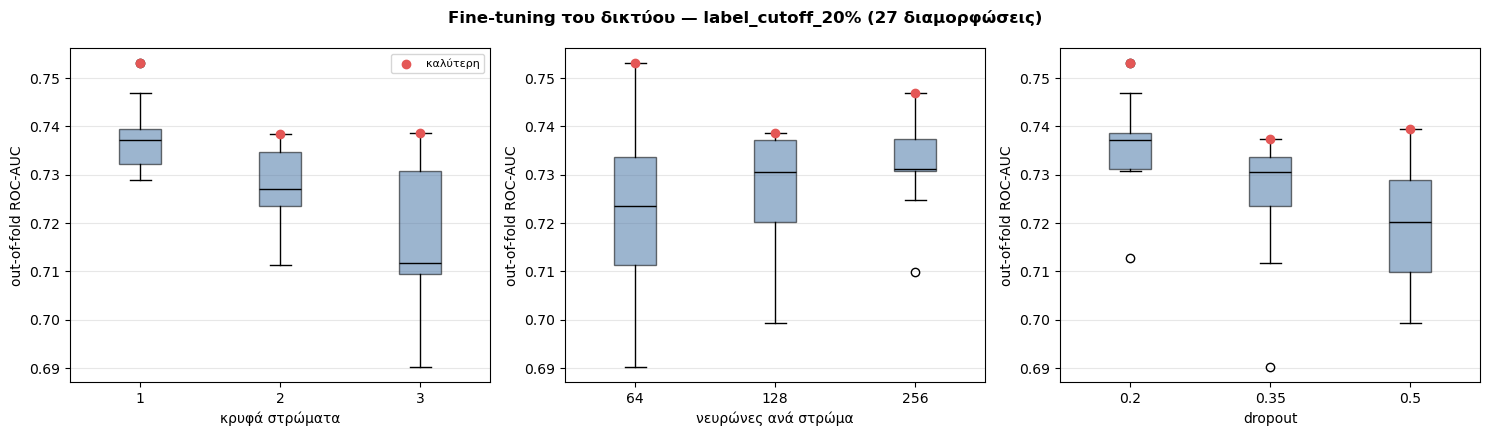

  ../results/Label_cutoff_20%/Neural_network/tuning_cutoff20.png


In [9]:
# ============ ΒΗΜΑ 1 — FINE-TUNING (5-fold CV, ROC-AUC) ============
# Κάθε διαμόρφωση αξιολογείται με τα ίδια 5 folds και κρατιέται αυτή με το
# μεγαλύτερο out-of-fold ROC-AUC — ίδιο πρωτόκολλο με τα προηγούμενα μοντέλα.
configs = [{'n_hidden': h, 'neurons': u, 'dropout': d}
           for h, u, d in itertools.product(N_HIDDEN, NEURONS, DROPOUT)]
print(f"{len(configs)} διαμορφώσεις × 5 folds = {5 * len(configs)} εκπαιδεύσεις\n")
print(f"{'#':>3} {'layers':>6} {'neurons':>8} {'dropout':>8} {'ROC-AUC':>9} {'εποχές':>7} {'χρόνος':>8}")
print('-' * 56)

rows, t_all = [], time.time()
for k, c in enumerate(configs, 1):
    t0 = time.time()
    oof, ep = cv_score(**c)
    auc = roc_auc_score(y, oof)
    rows.append({**c, 'ROC-AUC': auc, 'εποχές (μ.ό.)': ep, 'χρόνος (s)': time.time() - t0})
    print(f"{k:>3} {c['n_hidden']:>6} {c['neurons']:>8} {c['dropout']:>8} "
          f"{auc:>9.4f} {ep:>7.0f} {time.time() - t0:>7.0f}s")

tuning = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(f"\nΣυνολικός χρόνος: {(time.time() - t_all) / 60:.1f} λεπτά")

print("\n=== Top 10 διαμορφώσεις ===")
print(tuning.head(10).round(4).to_string(index=False))

best = tuning.iloc[0]
best_cfg = {'n_hidden': int(best['n_hidden']), 'neurons': int(best['neurons']),
            'dropout': float(best['dropout'])}
print(f"\n>>> ΚΑΛΥΤΕΡΗ: {best_cfg['n_hidden']} κρυφά στρώματα × {best_cfg['neurons']} νευρώνες, "
      f"dropout {best_cfg['dropout']}   (CV ROC-AUC {best['ROC-AUC']:.4f})")

print("\nΑποθηκεύτηκαν:")
_save(tuning.round(4), f'{OUT}/tuning_cutoff{TAG}.csv')
json.dump({'label_case': label_case, **best_cfg, 'cv_roc_auc': float(best['ROC-AUC']),
           'n_configs': len(configs), 'learning_rate': LEARNING_RATE},
          open(f'{OUT}/best_params_cutoff{TAG}.json', 'w'), indent=2)
print(f"  {OUT}/best_params_cutoff{TAG}.json")

# ---------------------------------------------------------------- διάγραμμα
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (col, lbl) in zip(axes, [('n_hidden', 'κρυφά στρώματα'),
                                 ('neurons', 'νευρώνες ανά στρώμα'),
                                 ('dropout', 'dropout')]):
    vals = sorted(tuning[col].unique())
    ax.boxplot([tuning.loc[tuning[col] == v, 'ROC-AUC'] for v in vals],
               tick_labels=[str(v) for v in vals], patch_artist=True,
               boxprops=dict(facecolor='#4C78A8', alpha=0.55), medianprops=dict(color='black'))
    ax.scatter(range(1, len(vals) + 1), [tuning.loc[tuning[col] == v, 'ROC-AUC'].max() for v in vals],
               color='#E45756', zorder=3, label='καλύτερη')
    ax.set_xlabel(lbl); ax.set_ylabel('out-of-fold ROC-AUC'); ax.grid(axis='y', alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle(f'Fine-tuning του δικτύου — {label_case} ({len(configs)} διαμορφώσεις)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{OUT}/tuning_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"  {OUT}/tuning_cutoff{TAG}.png")


## Βήμα 2 — Τελική εκπαίδευση

MLP 1×64 + LayerNorm (dropout 0.2, 3 seeds)

  seed   42: καλύτερη εποχή 77, val ROC-AUC 0.7464
  seed    7: καλύτερη εποχή 32, val ROC-AUC 0.7282
  seed  123: καλύτερη εποχή 11, val ROC-AUC 0.7343

Εκπαίδευση σε 34s


Model: "sequential_275"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_820 (Dense)               │ (None, 64)             │       107,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_545         │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_545 (Activation)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_545 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_821 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,797 (1.23 MB)

 Trainable params: 107,265 (419.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 214,532 (838.02 KB)

Το μοντέλο αποθηκεύτηκε στο ../models/mlp_cutoff20/


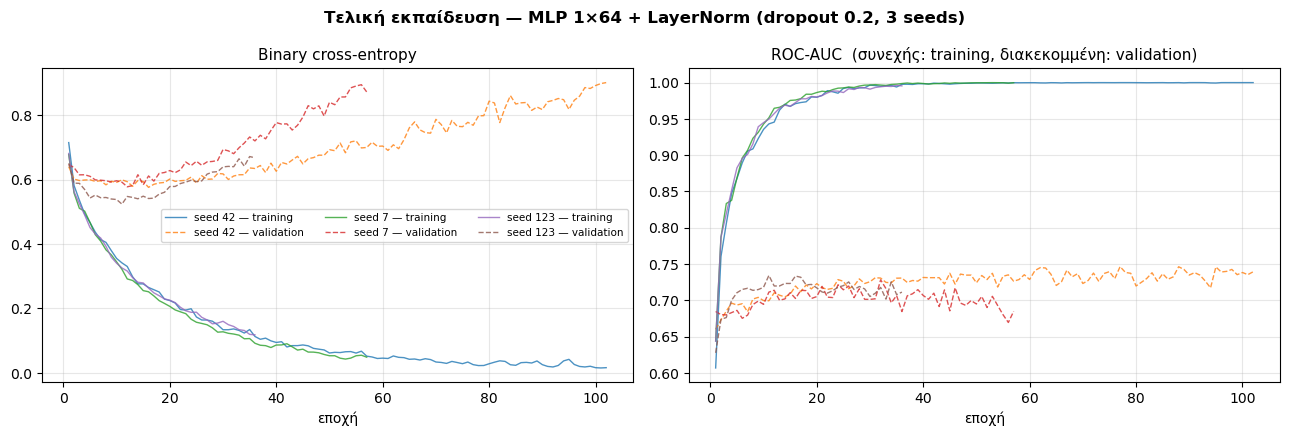

Αποθηκεύτηκε: ../results/Label_cutoff_20%/Neural_network/final_training_cutoff20.png


In [10]:
# ============ ΒΗΜΑ 2 — ΤΕΛΙΚΗ ΕΚΠΑΙΔΕΥΣΗ ΣΤΑ 1142 ΜΟΡΙΑ ============
# Με την καλύτερη διαμόρφωση του Βήματος 1. Εκπαιδεύονται SEEDS δίκτυα και η
# πρόβλεψη είναι ο μέσος όρος τους (ένα MLP εξαρτάται αισθητά από την αρχικοποίηση).
MODEL_NAME = (f"MLP {best_cfg['n_hidden']}×{best_cfg['neurons']} + LayerNorm "
              f"(dropout {best_cfg['dropout']}, {len(SEEDS)} seeds)")
print(f"{MODEL_NAME}\n")

scaler = RobustScaler().fit(X)
prep = lambda A: np.clip(scaler.transform(A), -CLIP, CLIP).astype('float32')
Xp = prep(X)

final_models, histories = [], []
t0 = time.time()
for s in SEEDS:
    keras.utils.set_random_seed(s)
    i_fit, i_val = next(StratifiedShuffleSplit(n_splits=1, test_size=VAL_FRAC,
                                               random_state=s).split(Xp, y))
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y[i_fit])
    model = build_model(Xp.shape[1], **best_cfg)
    stop = keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=PATIENCE,
                                         start_from_epoch=MIN_EPOCHS, restore_best_weights=True)
    h = model.fit(Xp[i_fit], y[i_fit], validation_data=(Xp[i_val], y[i_val]),
                  epochs=EPOCHS, batch_size=BATCH, class_weight={0: cw[0], 1: cw[1]},
                  callbacks=[stop], verbose=0)
    final_models.append(model)
    histories.append(h.history)
    print(f"  seed {s:4d}: καλύτερη εποχή {int(np.argmax(h.history['val_auc'])) + 1}, "
          f"val ROC-AUC {max(h.history['val_auc']):.4f}")

print(f"\nΕκπαίδευση σε {time.time() - t0:.0f}s")
model.summary()

# ------------------- αποθήκευση (τα χρειάζεται το neural_network_shap) -------------------
import joblib
MODEL_DIR = f'../models/mlp_cutoff{TAG}'
os.makedirs(MODEL_DIR, exist_ok=True)
for _s, _m in zip(SEEDS, final_models):
    _m.save(f'{MODEL_DIR}/model_seed{_s}.keras')
joblib.dump({'scaler': scaler, 'features': features, 'medians': medians, 'clip': CLIP},
            f'{MODEL_DIR}/preprocessing.joblib')
json.dump({'label_case': label_case, 'seeds': SEEDS, 'n_features': len(features),
           'n_train': int(len(y)), **best_cfg, 'learning_rate': LEARNING_RATE},
          open(f'{MODEL_DIR}/config.json', 'w'), indent=2)
print("Το μοντέλο αποθηκεύτηκε στο " + MODEL_DIR + "/")


def predict_proba(A):
    Ap = prep(A)
    return np.mean([m.predict(Ap, verbose=0).ravel() for m in final_models], axis=0)

# ------------------------------------------------------- καμπύλες εκπαίδευσης
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
for h, s in zip(histories, SEEDS):
    ep = np.arange(1, len(h['loss']) + 1)
    ax1.plot(ep, h['loss'], lw=1, alpha=0.8, label=f'seed {s} — training')
    ax1.plot(ep, h['val_loss'], lw=1, ls='--', alpha=0.8, label=f'seed {s} — validation')
    ax2.plot(ep, h['auc'], lw=1, alpha=0.8)
    ax2.plot(ep, h['val_auc'], lw=1, ls='--', alpha=0.8)
ax1.set_title('Binary cross-entropy', fontsize=11); ax1.set_xlabel('εποχή')
ax2.set_title('ROC-AUC  (συνεχής: training, διακεκομμένη: validation)', fontsize=11)
ax2.set_xlabel('εποχή')
for ax in (ax1, ax2):
    ax.grid(alpha=0.3)
ax1.legend(fontsize=7.5, ncol=len(SEEDS))
fig.suptitle(f'Τελική εκπαίδευση — {MODEL_NAME}', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{OUT}/final_training_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Αποθηκεύτηκε: {OUT}/final_training_cutoff{TAG}.png")


## Βήμα 3 — Αξιολόγηση στα Test set 1 και 2

  ../results/Label_cutoff_20%/Neural_network/predictions_test1_cutoff20.csv
  ../results/Label_cutoff_20%/Neural_network/predictions_test2_cutoff20.csv
=== Αξιολόγηση — label_cutoff_20% ===
 Κατώφλι   Test set   N  High  Low    MCC  ROC-AUC  Balanced Acc  Accuracy     F1  Precision  Sensitivity  Specificity  TP  FP  TN  FN
     0.5 Test set 1 287   214   73 0.3687   0.7792        0.6721    0.7735 0.8526     0.8282       0.8785       0.4658 188  39  34  26
     0.5 Test set 2 132   127    5 0.3708   0.9433        0.8409    0.8788 0.9333     0.9912       0.8819       0.8000 112   1   4  15

Αποθηκεύτηκαν:
  ../results/Label_cutoff_20%/Neural_network/evaluation_cutoff20.csv


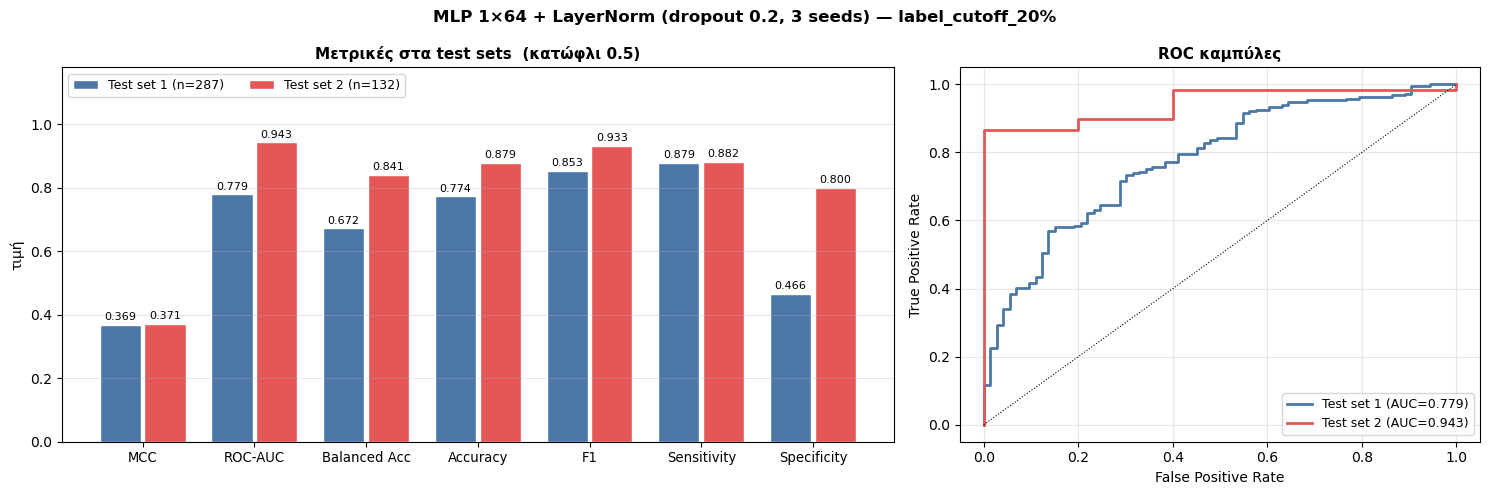

  ../results/Label_cutoff_20%/Neural_network/evaluation_cutoff20.png


In [11]:
# ============ ΒΗΜΑ 3 — ΑΞΙΟΛΟΓΗΣΗ ΣΤΑ TEST SET 1 ΚΑΙ 2 ============
# Το εκπαιδευμένο δίκτυο εφαρμόζεται στα δύο external test sets. Καμία προσαρμογή.
from sklearn.metrics import (matthews_corrcoef, f1_score, accuracy_score,
                             balanced_accuracy_score, precision_score, recall_score,
                             confusion_matrix, roc_curve)

_sheets = pd.read_excel('../Data/hob_data_set.xlsx', sheet_name=None)

rows, curves = [], {}
for ts, tf in [('Test set 1', 'test1'), ('Test set 2', 'test2')]:
    _lab = (_sheets[ts][['smile', label_case]]
            .rename(columns={'smile': 'SMILES'}).drop_duplicates(subset='SMILES'))
    _d = pd.read_csv(f'../Data/{tf}_descriptors_RAW.csv').drop_duplicates(subset='SMILES')
    _m = _d.merge(_lab, on='SMILES', how='inner')
    _m = _m[_m[label_case].notna()].reset_index(drop=True)

    X_test = _m[features].apply(pd.to_numeric, errors='coerce').fillna(medians)
    y_test = _m[label_case].astype(int).to_numpy()
    proba = predict_proba(X_test)
    pred = (proba >= THRESHOLD).astype(int)
    curves[ts] = (y_test, proba)

    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    rows.append({
        'Test set': ts, 'N': len(y_test), 'High': int(y_test.sum()), 'Low': int((y_test == 0).sum()),
        'MCC': matthews_corrcoef(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Balanced Acc': balanced_accuracy_score(y_test, pred),
        'Accuracy': accuracy_score(y_test, pred),
        'F1': f1_score(y_test, pred, zero_division=0),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Sensitivity': recall_score(y_test, pred),
        'Specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    })
    _save(pd.DataFrame({'SMILES': _m['SMILES'], 'y_true': y_test,
                        'y_pred': pred, 'proba_High': proba}),
          f'{OUT}/predictions_{tf}_cutoff{TAG}.csv')

results = pd.DataFrame(rows)
results.insert(0, 'Μοντέλο', MODEL_NAME)
results.insert(1, 'Κατώφλι', THRESHOLD)

print(f"=== Αξιολόγηση — {label_case} ===")
print(results.drop(columns='Μοντέλο').round(4).to_string(index=False))
print("\nΑποθηκεύτηκαν:")
_save(results.round(4), f'{OUT}/evaluation_cutoff{TAG}.csv')

# ---------------------------------------------------------------- διαγράμματα
METRICS = ['MCC', 'ROC-AUC', 'Balanced Acc', 'Accuracy', 'F1', 'Sensitivity', 'Specificity']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.6, 1]})

x = np.arange(len(METRICS))
w = 0.8 / len(results)
_cols = ['#4C78A8', '#E45756']
for k, (_, r) in enumerate(results.iterrows()):
    pos = x + (k - (len(results) - 1) / 2) * w
    vals = [r[m] for m in METRICS]
    ax1.bar(pos, vals, width=w * 0.92, color=_cols[k], edgecolor='white',
            label=f"{r['Test set']} (n={r['N']})")
    for p, v in zip(pos, vals):
        ax1.text(p, v + 0.015, f'{v:.3f}', ha='center', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(METRICS, fontsize=9.5)
ax1.set_ylim(0, 1.18); ax1.set_ylabel('τιμή')
ax1.set_title(f'Μετρικές στα test sets  (κατώφλι {THRESHOLD})', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3); ax1.legend(fontsize=9, loc='upper left', ncol=2)

for k, (ts, (yt, pp)) in enumerate(curves.items()):
    fpr, tpr, _ = roc_curve(yt, pp)
    ax2.plot(fpr, tpr, lw=2, color=_cols[k], label=f'{ts} (AUC={roc_auc_score(yt, pp):.3f})')
ax2.plot([0, 1], [0, 1], 'k:', lw=0.8)
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC καμπύλες', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right'); ax2.grid(alpha=0.3)

fig.suptitle(f'{MODEL_NAME} — {label_case}', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{OUT}/evaluation_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"  {OUT}/evaluation_cutoff{TAG}.png")
